Load the Hazard Feature Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("HAZARD_FEATURE_DATASET.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["hazard_time"] = pd.to_datetime(df["hazard_time"], utc=True)
df["t_offset"] = (df["timestamp"] - df["hazard_time"]).dt.total_seconds()

SPEED (Enhanced Feature Speed: gps_speed)

In [ ]:
avg = df.groupby("t_offset")["gps_speed"].mean()
std = df.groupby("t_offset")["gps_speed"].std()

plt.figure(figsize=(14,6))
plt.plot(avg.index, avg.values, color="red", linewidth=2, label="Avg GPS Speed")
plt.fill_between(avg.index, avg - std, avg + std, color="red", alpha=0.2)

plt.axvline(0, color="black", linestyle="--", label="Hazard Moment")
plt.title("GPS Speed Around Hazard Events", fontsize=15)
plt.xlabel("Seconds Relative to Hazard")
plt.ylabel("Speed (m/s)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

ACCELERATION (Rolling AccX Mean)

In [ ]:
avg_acc = df.groupby("t_offset")["accx_5s_mean"].mean()
std_acc = df.groupby("t_offset")["accx_5s_mean"].std()

plt.figure(figsize=(14,6))
plt.plot(avg_acc.index, avg_acc.values, color="blue", linewidth=2, label="Avg AccX Mean")
plt.fill_between(avg_acc.index, avg_acc - std_acc, avg_acc + std_acc, color="blue", alpha=0.2)

plt.axvline(0, color="black", linestyle="--", label="Hazard Moment")
plt.title("Rolling Mean Forward Acceleration Around Hazard")
plt.xlabel("Seconds Relative to Hazard")
plt.ylabel("AccX (rolling mean)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

ACCELERATION (Rolling AccX Min)

In [ ]:
avg_min = df.groupby("t_offset")["accx_5s_min"].mean()
std_min = df.groupby("t_offset")["accx_5s_min"].std()

plt.figure(figsize=(14,6))
plt.plot(avg_min.index, avg_min.values, color="purple", linewidth=2, label="Avg AccX Min (Hard Braking)")
plt.fill_between(avg_min.index, avg_min - std_min, avg_min + std_min, color="purple", alpha=0.3)

plt.axvline(0, color="black", linestyle="--")
plt.title("Rolling Min AccX Around Hazard")
plt.xlabel("Seconds Relative to Hazard")
plt.ylabel("AccX Min (Hard brake indicator)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Percentage of hazards occurring under each condition

In [ ]:
flags = ["is_slippery", "is_icy", "is_snowy", "is_wet", "black_ice_risk"]

condition_rates = df[flags].mean() * 100

plt.figure(figsize=(10,5))
sns.barplot(x=condition_rates.index, y=condition_rates.values, palette="Reds")
plt.ylabel("Percentage of Hazard Window Rows (%)")
plt.title("Road Condition Presence During Hazard Windows")
plt.xticks(rotation=30)
plt.show()

Time-series of road grip (grip value)

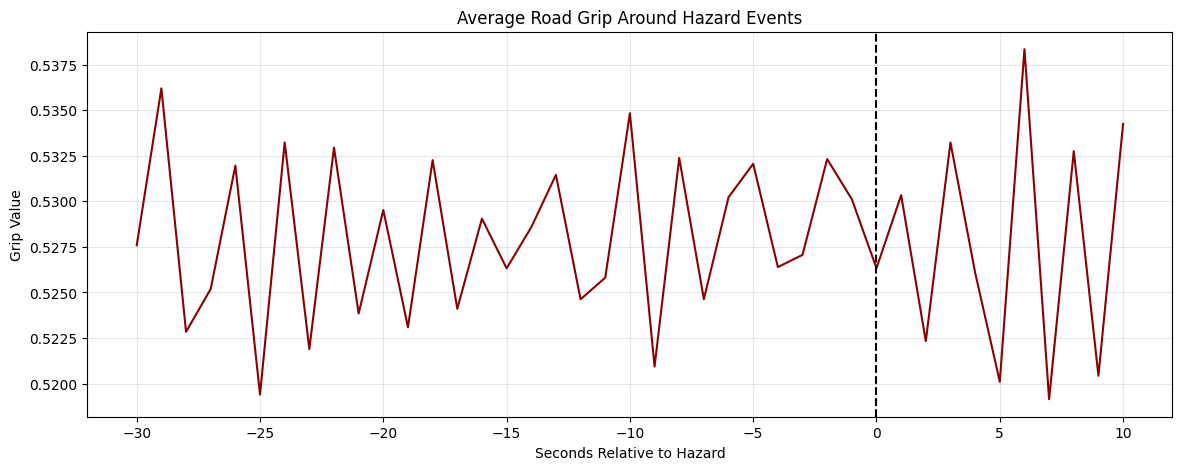

In [8]:
avg_grip = df.groupby("t_offset")["grip"].mean()

plt.figure(figsize=(14,5))
plt.plot(avg_grip.index, avg_grip.values, color="darkred")
plt.axvline(0, color="black", linestyle="--")
plt.title("Average Road Grip Around Hazard Events")
plt.xlabel("Seconds Relative to Hazard")
plt.ylabel("Grip Value")
plt.grid(alpha=0.3)
plt.show()

Surface Temperature

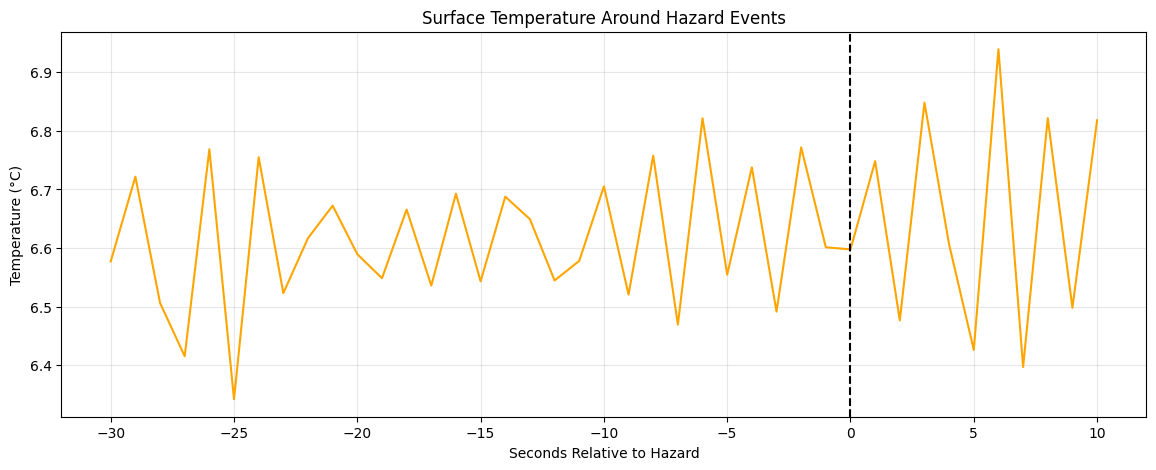

In [9]:
avg_temp = df.groupby("t_offset")["surface_temperature"].mean()

plt.figure(figsize=(14,5))
plt.plot(avg_temp.index, avg_temp.values, color="orange")
plt.axvline(0, color="black", linestyle="--")
plt.title("Surface Temperature Around Hazard Events")
plt.xlabel("Seconds Relative to Hazard")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)
plt.show()

Black Ice Risk Trend

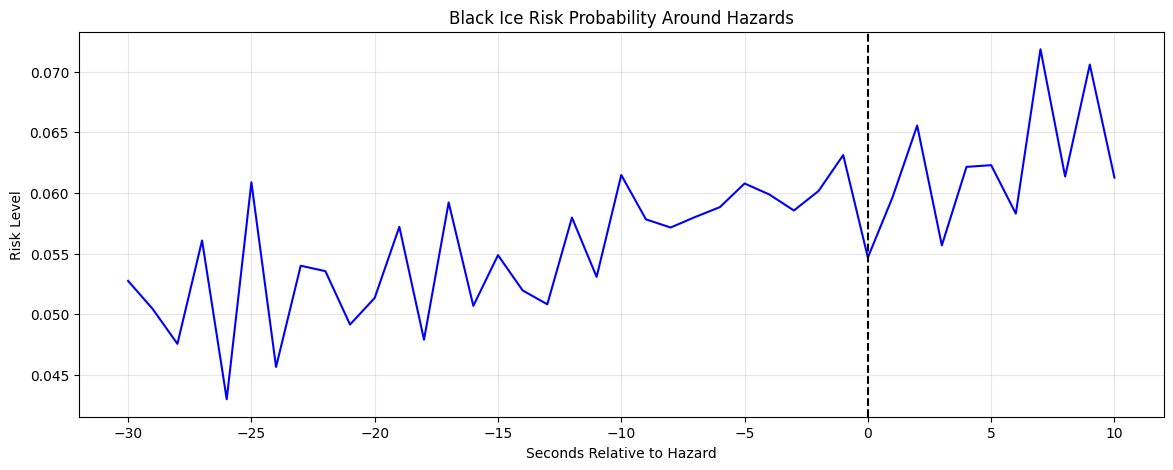

In [10]:
avg_bi = df.groupby("t_offset")["black_ice_risk"].mean()

plt.figure(figsize=(14,5))
plt.plot(avg_bi.index, avg_bi.values, color="blue")
plt.axvline(0, color="black", linestyle="--")
plt.title("Black Ice Risk Probability Around Hazards")
plt.xlabel("Seconds Relative to Hazard")
plt.ylabel("Risk Level")
plt.grid(alpha=0.3)
plt.show()

CORRELATION HEATMAP

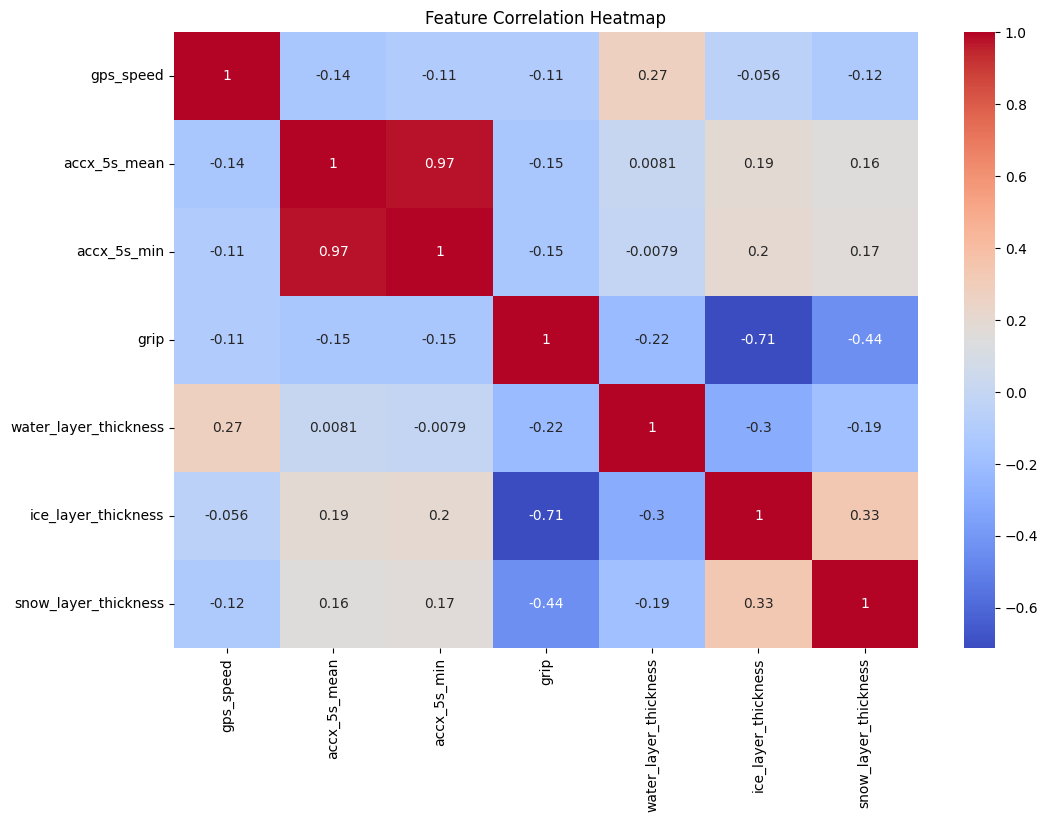

In [11]:
plt.figure(figsize=(12,8))

selected = [
    "gps_speed",
    "accx_5s_mean",
    "accx_5s_min",
    "grip",
    "water_layer_thickness",
    "ice_layer_thickness",
    "snow_layer_thickness",
]

sns.heatmap(df[selected].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

HAZARD LOCATIONS

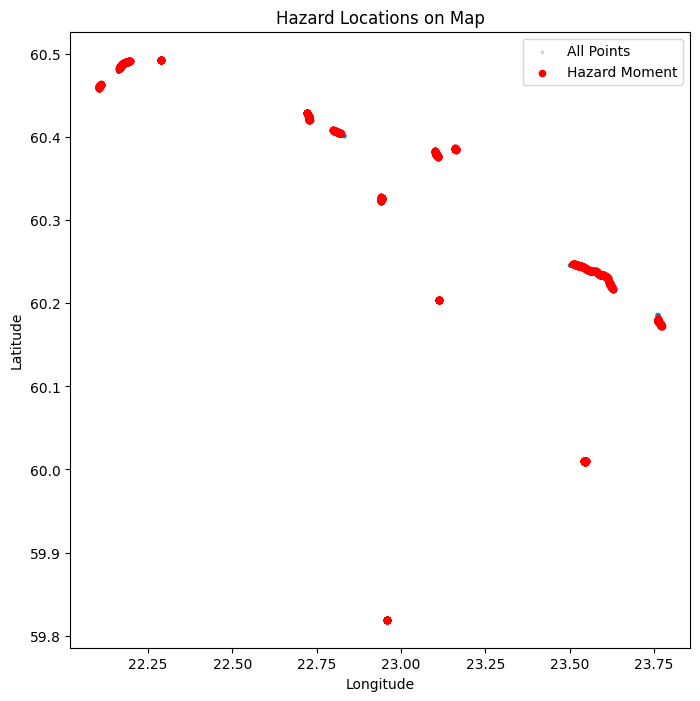

In [12]:
plt.figure(figsize=(8,8))

plt.scatter(df["lon"], df["lat"], s=3, alpha=0.2, label="All Points")
plt.scatter(df[df["t_offset"] == 0]["lon"], df[df["t_offset"] == 0]["lat"], color="red", s=20, label="Hazard Moment")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.title("Hazard Locations on Map")
plt.show()